In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import warnings
warnings.filterwarnings('ignore')   

In [7]:
df = pd.read_csv(r"D:\DA\Archive\GitHUB\Forage-QA\Nat_Gas.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     str    
 1   Prices  48 non-null     float64
dtypes: float64(1), str(1)
memory usage: 900.0 bytes


In [10]:
df.isnull().sum()
df.shape

(48, 2)

In [11]:
df.head(12)

,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [23]:
df.isna().sum()
df.index.name

'Dates'

In [19]:
df=df.sort_values(by='Dates')
df=df.asfreq('ME')
df.head(12)

,Prices
Dates,
2020-10-31,10.10
2020-11-30,10.30
2020-12-31,11.00
2021-01-31,10.90
2021-02-28,10.90
2021-03-31,10.90
2021-04-30,10.40
2021-05-31,9.84
2021-06-30,10.00


In [20]:
df.index = pd.to_datetime(df.index)
df.info()
print(df.columns)

<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2020-10-31 to 2024-09-30
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Prices  48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes
Index(['Prices'], dtype='str')


There are no missing or null values in the dataset.

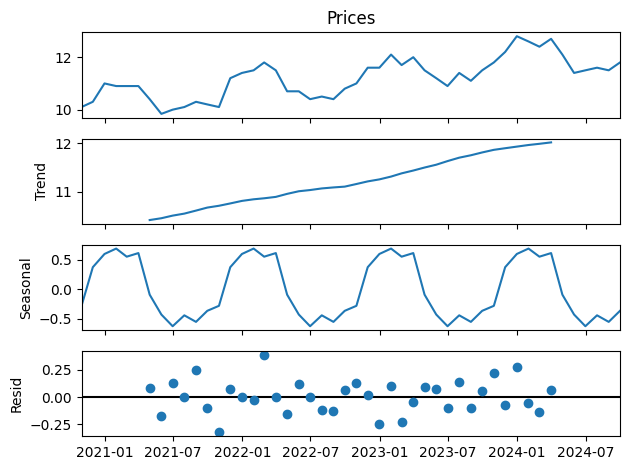

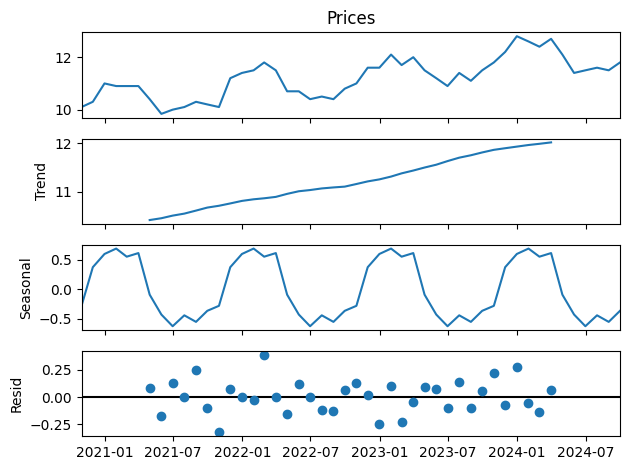

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

result=seasonal_decompose(df['Prices'],model='additive',period=12)

result.plot()